In [14]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [15]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",0.049103,0.298817,0.298817,1.0
…,…,…,…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",0.003124,-0.005248,0.005248,-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0


In [16]:
# Configuration and paths
mac = 20
pheno_list_type = None

# Select which experimental assay to analyze (set to None to include all)
# Options: 'scaled_fitness', 'DMS_score_combined', or None
# selected_exp_assay = 'scaled_fitness'  # aPCA only
selected_exp_assay = 'DMS_score_combined'  # Combined ProteinGym + Marsh VEP
# selected_exp_assay = None  # All experimental assays

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_expAssays.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

# Filter to selected experimental assay if specified
if selected_exp_assay is not None:
    anno_config_df = anno_config_df.filter(
        (pl.col('category') != 'exp_assays') | (pl.col('annotation') == selected_exp_assay)
    )
    print(f"Selected experimental assay: {selected_exp_assay}")

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Selected experimental assay: DMS_score_combined


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""exp_assays""","""DMS_score_combined""","""#4DB6AC""","""DMS (combined)""",-1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""score_pai3d""","""#feb72d""","""PrimateAI-3D""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…
"""protein_domains""","""low_complexity_domain""","""#FF9933""","""Low Complexity Domain""",1
"""loftee_protein_domains""","""loftee_disorder""","""#E31A1C""","""Disordered Domain""",1
"""loftee_protein_domains""","""loftee_lip""","""#1E90FF""","""Linear Interacting Peptides""",1


In [17]:
LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']

# --- 1. aPCA (Beltran et al., Nature 2025) ---
# One fitness score per variant, 447 genes
aPCA = (
    pl.read_parquet(f"{LOCAL_EXP_DIR}/aPCA_Beltran_Nature_2025.parquet")
    .drop_nulls(subset=id_cols)
    .group_by(id_cols).agg(pl.col('scaled_fitness').mean())
)

# --- 2. Catalog DMS experiments per gene ---
# Don't average - different experiments measure different things at different scales

proteingym_full = pl.read_parquet(f"{LOCAL_EXP_DIR}/DMS_ProteinGym_substitutions.parquet")
marsh_full = pl.read_parquet(f"{LOCAL_EXP_DIR}/DMS_Marsh_VEP.parquet")

# Get unique experiments per gene from ProteinGym
proteingym_experiments = (
    proteingym_full
    .select(['region', 'file_name'])
    .unique()
    .group_by('region')
    .agg(
        n_experiments = pl.len(),
        experiments = pl.col('file_name').alias('experiments')
    )
    .with_columns(source = pl.lit('ProteinGym'))
)

# Get unique experiments per gene from Marsh VEP
marsh_experiments = (
    marsh_full
    .select(['region', 'DMS_assay'])
    .unique()
    .group_by('region')
    .agg(
        n_experiments = pl.len(),
        experiments = pl.col('DMS_assay').alias('experiments')
    )
    .with_columns(source = pl.lit('Marsh VEP'))
)

# Combine catalogs
dms_catalog = pl.concat([proteingym_experiments, marsh_experiments])

print("DMS Experiment Catalog:")
print(f"ProteinGym: {proteingym_experiments.shape[0]} genes, {proteingym_experiments['n_experiments'].sum()} total experiments")
print(f"Marsh VEP: {marsh_experiments.shape[0]} genes, {marsh_experiments['n_experiments'].sum()} total experiments")
print(f"\nTotal unique genes with DMS data: {dms_catalog['region'].n_unique()}")

# Show genes with multiple experiments
multi_exp_genes = dms_catalog.filter(pl.col('n_experiments') > 1).sort('n_experiments', descending=True)
print(f"\nGenes with multiple DMS experiments: {multi_exp_genes.shape[0]}")

# For now, keep aPCA only (don't include DMS in the analysis since we can't average them)
exp_anno_df = aPCA
exp_assay_columns = ['scaled_fitness']

print(f"\naPCA: {aPCA.shape[0]} variants, {aPCA['region'].n_unique()} genes")

# Display the catalog
dms_catalog.sort(['region', 'source'])

DMS Experiment Catalog:
ProteinGym: 93 genes, 118 total experiments
Marsh VEP: 39 genes, 136 total experiments

Total unique genes with DMS data: 98

Genes with multiple DMS experiments: 49

aPCA: 607560 variants, 446 genes


region,n_experiments,experiments,source
str,u64,list[str],str
"""ENSG00000007372""",4,"[""DMS_le9"", ""DMS_blx"", … ""DMS_blx_geneticin""]","""Marsh VEP"""
"""ENSG00000012048""",1,"[""BRCA1_HUMAN_Findlay_2018""]","""ProteinGym"""
"""ENSG00000036473""",1,"[""OTC_HUMAN_Lo_2023""]","""ProteinGym"""
"""ENSG00000039600""",1,"[""SOX30_HUMAN_Tsuboyama_2023_7JJK""]","""ProteinGym"""
"""ENSG00000055118""",1,"[""KCNH2_HUMAN_Kozek_2020""]","""ProteinGym"""
…,…,…,…
"""ENSG00000276536""",1,"[""RASH_HUMAN_Bandaru_2017""]","""ProteinGym"""
"""ENSG00000284792""",3,"[""DMS_b"", ""DMS_highqual_b"", ""DMS""]","""Marsh VEP"""
"""ENSG00000284792""",2,"[""PTEN_HUMAN_Mighell_2018"", ""PTEN_HUMAN_Matreyek_2021""]","""ProteinGym"""


In [6]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Parse amino acid coordinates and join with experimental assay data
anno = (
    anno
    .filter(
        pl.col('amino_acids').is_not_null(),
        pl.col('amino_acids').str.contains("/"),
        ~pl.col('protein_position').str.contains("-")
    )
    .with_columns(
        pl.col("amino_acids").str.split("/").list.get(0).alias("ref_aa"),
        pl.col("amino_acids").str.split("/").list.get(1).alias("alt_aa"),
        pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
    )
    .join(
        exp_anno_df.lazy(),
        on=['ref_aa', 'aa_position', 'alt_aa', 'region'],
        how='left'
    )
    # Keep ALL missense variants (exp assay scores will be null where unavailable)
)

# Standard variant filters
anno = (
    anno
    .filter(
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True),

        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
)

selected_categories = ['exp_assays', 'missense', 'genetic_diversity', 'conservation']

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    .drop_nulls()
)

print(f"Annotation table: {anno.shape[0]} variants, {anno['region'].n_unique()} genes")
print(f"Selected annotations: {selected_annos}")
anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_155767/2255576469.py:49: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_155767/2255576469.py:57: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Annotation table: 397 variants, 6 genes
Selected annotations: ['DMS_score_combined', 'gpn_score', 'esmscoremissense', 'am_pathogenicity', 'score_pai3d', 'cadd_raw', 'verphylop']


DMS_score_combined,gpn_score,esmscoremissense,region,score_pai3d,am_pathogenicity,verphylop,cadd_raw,id
f64,f32,f32,str,f32,f32,f32,f32,str
-0.052308,-7.88,-15.664,"""ENSG00000141458""",0.970434,0.9954,11.288,5.15649,"""chr18:23544474:G:C"""
0.515306,-10.78,-14.061,"""ENSG00000106633""",0.97978,0.9802,8.532,5.681676,"""chr7:44146580:A:G"""
0.680537,-7.24,-9.032,"""ENSG00000106633""",0.769001,0.1845,6.42,6.544526,"""chr7:44147690:G:A"""
0.817307,-5.33,-5.203,"""ENSG00000106633""",0.459803,0.123,1.143,2.310223,"""chr7:44145556:G:T"""
-1.41996,-10.2,-13.389,"""ENSG00000171862""",0.884906,0.9999,7.112,5.604109,"""chr10:87952142:C:A"""
…,…,…,…,…,…,…,…,…
0.775951,-3.21,-3.958,"""ENSG00000106633""",0.299844,0.1436,0.261,2.436432,"""chr7:44188938:C:T"""
0.718079,-2.74,-5.344,"""ENSG00000141458""",0.564756,0.1463,7.842,3.386407,"""chr18:23544498:G:A"""
0.792253,-10.68,-11.114,"""ENSG00000106633""",0.844608,0.8908,7.493,5.118336,"""chr7:44153306:C:T"""


In [7]:
melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr18:23544474:G:C""","""ENSG00000141458""","""DMS_score_combined""",-0.052308
"""chr7:44146580:A:G""","""ENSG00000106633""","""DMS_score_combined""",0.515306
"""chr7:44147690:G:A""","""ENSG00000106633""","""DMS_score_combined""",0.680537
"""chr7:44145556:G:T""","""ENSG00000106633""","""DMS_score_combined""",0.817307
"""chr10:87952142:C:A""","""ENSG00000171862""","""DMS_score_combined""",-1.41996
…,…,…,…
"""chr7:44188938:C:T""","""ENSG00000106633""","""verphylop""",0.261
"""chr18:23544498:G:A""","""ENSG00000141458""","""verphylop""",7.842
"""chr7:44153306:C:T""","""ENSG00000106633""","""verphylop""",7.493


In [8]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/quant_pheno_loftee_mac20_EURunrelated_mis
s20per_appv_percentiles_small.parquet" already exists but -f/--overwrite was
not set


In [9]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Build the main lazy query plan
# Join order: appv → id_region (adds region) → gene_trait_df (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    appv
    .join(id_region, on='id', how='inner')
    .join(
        gene_trait_df[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )
    .filter(pl.col('annotation') != 'loftee_hc')

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .select(["region", "phenotype", "annotation", "n_variants", "correlation"])
    
    .drop_nans().drop_nulls()
        
    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan
    
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (34, 14)


region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64
"""ENSG00000170180""","""high_light_scatter_reticulocyt…","""cadd_raw""",6,-0.2,"""#1f77b4""","""CADD Raw""",1,0.002187,0.294132,0.294132,1.0,-0.2,-0.679967
"""ENSG00000170180""","""high_light_scatter_reticulocyt…","""gpn_score""",6,0.314286,"""#942c80""","""GPN-MSA""",-1,0.002187,0.294132,0.294132,1.0,-0.314286,-1.068519
"""ENSG00000170180""","""high_light_scatter_reticulocyt…","""esmscoremissense""",6,-0.542857,"""#feb72d""","""ESM1v""",-1,0.002187,0.294132,0.294132,1.0,0.542857,1.845624
"""ENSG00000170180""","""high_light_scatter_reticulocyt…","""DMS_score_combined""",6,0.2,"""#4DB6AC""","""DMS (combined)""",-1,0.002187,0.294132,0.294132,1.0,-0.2,-0.679967
"""ENSG00000170180""","""high_light_scatter_reticulocyt…","""am_pathogenicity""",6,0.714286,"""#feb72d""","""AlphaMissense""",1,0.002187,0.294132,0.294132,1.0,0.714286,2.428453
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000141458""","""red_blood_cell_erythrocyte_dis…","""DMS_score_combined""",50,-0.052485,"""#4DB6AC""","""DMS (combined)""",-1,0.027461,0.092346,0.092346,1.0,0.052485,0.568353
"""ENSG00000141458""","""red_blood_cell_erythrocyte_dis…","""gpn_score""",50,-0.003073,"""#942c80""","""GPN-MSA""",-1,0.027461,0.092346,0.092346,1.0,0.003073,0.033281
"""ENSG00000141458""","""red_blood_cell_erythrocyte_dis…","""verphylop""",50,0.002498,"""#942c80""","""Vertebrate PhyloP""",1,0.027461,0.092346,0.092346,1.0,0.002498,0.027053


In [10]:
consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000106633""","""glycated_haemoglobin_hba1c_int""","""cadd_raw""",172,0.460525,"""#1f77b4""","""CADD Raw""",1,2.2211e-27,0.266069,0.266069,1.0,0.460525,1.730847,7
"""ENSG00000106633""","""glycated_haemoglobin_hba1c_int""","""esmscoremissense""",172,-0.53307,"""#feb72d""","""ESM1v""",-1,2.2211e-27,0.266069,0.266069,1.0,0.53307,2.003502,7
"""ENSG00000106633""","""glycated_haemoglobin_hba1c_int""","""DMS_score_combined""",172,-0.45057,"""#4DB6AC""","""DMS (combined)""",-1,2.2211e-27,0.266069,0.266069,1.0,0.45057,1.693433,7
"""ENSG00000106633""","""glycated_haemoglobin_hba1c_int""","""gpn_score""",172,-0.417748,"""#942c80""","""GPN-MSA""",-1,2.2211e-27,0.266069,0.266069,1.0,0.417748,1.570073,7
"""ENSG00000106633""","""glycated_haemoglobin_hba1c_int""","""am_pathogenicity""",172,0.577217,"""#feb72d""","""AlphaMissense""",1,2.2211e-27,0.266069,0.266069,1.0,0.577217,2.169428,7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000141458""","""red_blood_cell_erythrocyte_dis…","""DMS_score_combined""",50,-0.052485,"""#4DB6AC""","""DMS (combined)""",-1,0.027461,0.092346,0.092346,1.0,0.052485,0.568353,7
"""ENSG00000141458""","""red_blood_cell_erythrocyte_dis…","""gpn_score""",50,-0.003073,"""#942c80""","""GPN-MSA""",-1,0.027461,0.092346,0.092346,1.0,0.003073,0.033281,7
"""ENSG00000141458""","""red_blood_cell_erythrocyte_dis…","""verphylop""",50,0.002498,"""#942c80""","""Vertebrate PhyloP""",1,0.027461,0.092346,0.092346,1.0,0.002498,0.027053,7


In [11]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


No significant adjacent pairs found


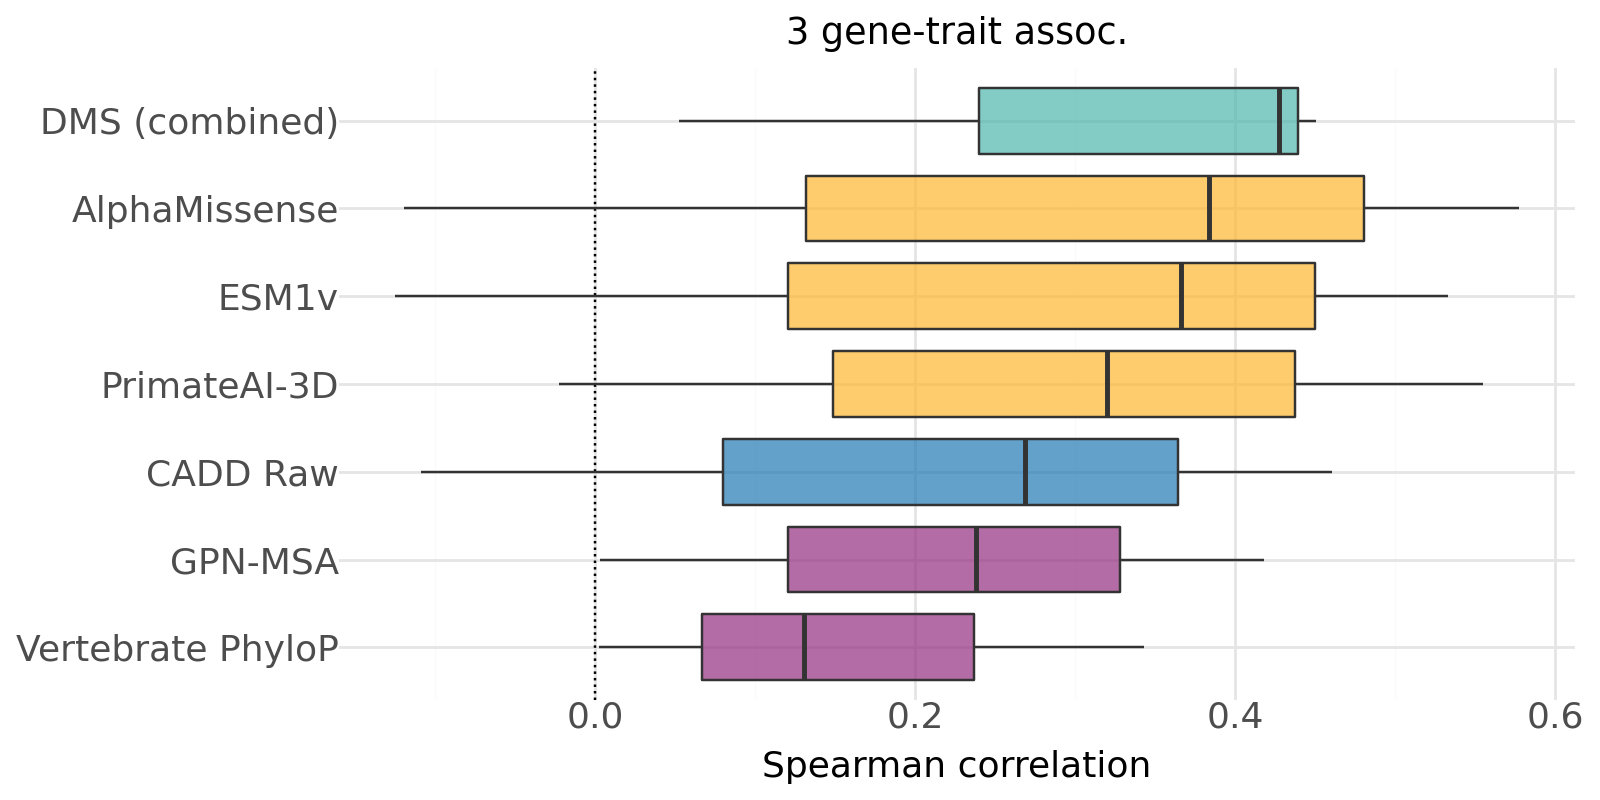

In [13]:
# Compute pairwise Wilcoxon tests between adjacent boxes and add asterisks
from scipy.stats import wilcoxon

plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and get ordering
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# Get ordered annotations (not labels)
ordered_annos = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("annotation")
    .unique(maintain_order=True)
    .to_series()
)

corr_pl = corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))
color_dict = dict(corr_pl.select("annotation", "color").unique().iter_rows())

# Compute Wilcoxon tests for adjacent pairs (in plot order: bottom to top)
sig_pairs = []
for i in range(len(ordered_annos) - 1):
    anno_below = ordered_annos[i]
    anno_above = ordered_annos[i + 1]
    
    df_below = filt_corr_df.filter(pl.col("annotation") == anno_below).select(["region", "phenotype", "corr_beta"])
    df_above = filt_corr_df.filter(pl.col("annotation") == anno_above).select(["region", "phenotype", "corr_beta"])
    
    merged = df_below.join(df_above, on=["region", "phenotype"], how="inner", suffix="_above")
    
    if merged.height > 0:
        # One-sided test: is anno_above significantly GREATER than anno_below?
        stat, pval = wilcoxon(
            merged["corr_beta_above"].to_numpy(), 
            merged["corr_beta"].to_numpy(), 
            alternative="greater"
        )
        
        if pval < 0.05:
            sig_pairs.append({
                'anno_below': anno_below,
                'anno_above': anno_above,
                'y_pos': i + 0.5,  # Position between the two boxes
                'pval': pval
            })

# Create asterisk annotations
sig_df = pl.DataFrame(sig_pairs) if sig_pairs else None

# Plot with significance asterisks
plot = (
    ggplot(corr_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pl[['region', 'phenotype']].unique().shape[0]} gene-trait assoc."
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

# Add asterisks for significant adjacent pairs
if sig_df is not None and sig_df.height > 0:
    # Get max x value for asterisk placement
    max_x = corr_pl[plotting_col].max() * 1.05
    
    sig_annot = sig_df.with_columns(
        x = pl.lit(max_x),
        label_text = pl.when(pl.col('pval') < 0.001).then(pl.lit('***'))
                      .when(pl.col('pval') < 0.01).then(pl.lit('**'))
                      .when(pl.col('pval') < 0.05).then(pl.lit('*'))
                      .otherwise(pl.lit(''))
    )
    
    plot = plot + geom_text(
        sig_annot, 
        aes(x='x', y='y_pos', label='label_text'),
        size=16,
        color='black',
        ha='left'
    )
    
    print(f"Found {sig_df.height} significant adjacent pairs:")
    for row in sig_df.iter_rows(named=True):
        print(f"  {row['anno_above']} > {row['anno_below']} (p={row['pval']:.4f})")
else:
    print("No significant adjacent pairs found")

plot